In [136]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix
import os
%matplotlib inline

In [138]:
# Definir carpetas de comparación disponibles
selected_comparison_folder = 'comparision_resnet'

available_folders = {
    'comparison': [
        'densenet121_20260109_004724',
        'efficientnet-b0_20260109_084143',
        'resnet50_20260110_001917'
    ],
    'comparison_02': [
        'densenet121_20260111_090433',
        'efficientnet-b0_20260111_015704',
        'resnet50_20260111_002544'
    ],
    'comparision_best_hiperparamentros': [
        'densenet121_20260112_191317',
        'efficientnet-b0_20260112_190917',
        'resnet50_20260114_071215'
    ],
    'comparision_resnet': [
        'resnet50_20260110_001917-normal',
        'resnet50_20260112_032701-data.augmentation',
        'resnet50_20260111_220602-dense256',  # ← AÑADE ESTA LÍNEA
        'resnet50_20260103_235009-batchzise-mayor',  
        'resnet50_20260111_215331-unfreeze-max',
        'resnet50_20260112_035343-focal-loss',
        'resnet50_20260113_021021-mas-epocas',
    ],
}

selected_models = available_folders[selected_comparison_folder]

print(f"Carpeta de comparación seleccionada: {selected_comparison_folder}")
print(f"Modelos seleccionados: {selected_models}")

Carpeta de comparación seleccionada: comparision_resnet
Modelos seleccionados: ['resnet50_20260110_001917-normal', 'resnet50_20260112_032701-data.augmentation', 'resnet50_20260111_220602-dense256', 'resnet50_20260103_235009-batchzise-mayor', 'resnet50_20260111_215331-unfreeze-max', 'resnet50_20260112_035343-focal-loss', 'resnet50_20260113_021021-mas-epocas']


## 5. Configuración: fase y modelos a comparar


En esta sección definimos la fase y los modelos para cargar múltiples `scores.npz` y visualizar los resultados de forma comparativa.


=== Cargando modelo: resnet50_20260110_001917-normal ===
Buscando CSV en: ../outputs/comparision_resnet/resnet50_20260110_001917-normal/prediction_scores_test.csv
✓ Datos cargados: 17125 muestras
  - Distribución de clases: [15067  2058]
  - Rango de scores: [0.0000, 1.0000]
  - Configuración: 1 clase(s), sigmoid=True

ResNet50 (baseline)
Classification Report (test)
              precision    recall  f1-score   support

      Benign     0.9727    0.8998    0.9348     15067
   Malignant     0.5264    0.8149    0.6396      2058

    accuracy                         0.8896     17125
   macro avg     0.7495    0.8574    0.7872     17125
weighted avg     0.9190    0.8896    0.8994     17125

  - d' = 2.373 (μ_maligno=0.786, μ_benigno=0.120)

=== Cargando modelo: resnet50_20260112_032701-data.augmentation ===
Buscando CSV en: ../outputs/comparision_resnet/resnet50_20260112_032701-data.augmentation/prediction_scores_test.csv
✓ Datos cargados: 17125 muestras
  - Distribución de clases: [1506

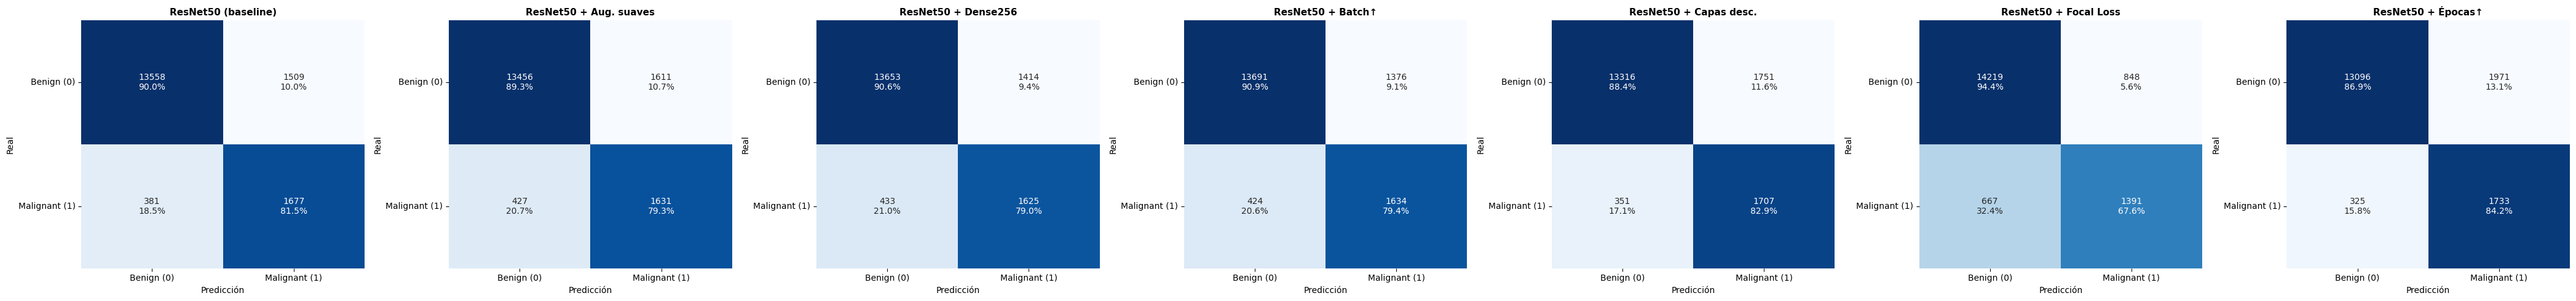


📈 Generando curvas ROC...

=== Cargando modelo: resnet50_20260110_001917-normal ===
Buscando CSV en: ../outputs/comparision_resnet/resnet50_20260110_001917-normal/prediction_scores_test.csv
✓ Datos cargados: 17125 muestras
  - Distribución de clases: [15067  2058]
  - Rango de scores: [0.0000, 1.0000]
  - Configuración: 1 clase(s), sigmoid=True

=== Cargando modelo: resnet50_20260112_032701-data.augmentation ===
Buscando CSV en: ../outputs/comparision_resnet/resnet50_20260112_032701-data.augmentation/prediction_scores_test.csv
✓ Datos cargados: 17125 muestras
  - Distribución de clases: [15067  2058]
  - Rango de scores: [0.0000, 1.0000]
  - Configuración: 1 clase(s), sigmoid=True

=== Cargando modelo: resnet50_20260111_220602-dense256 ===
Buscando CSV en: ../outputs/comparision_resnet/resnet50_20260111_220602-dense256/prediction_scores_test.csv
✓ Datos cargados: 17125 muestras
  - Distribución de clases: [15067  2058]
  - Rango de scores: [0.0000, 1.0000]
  - Configuración: 1 clase(s

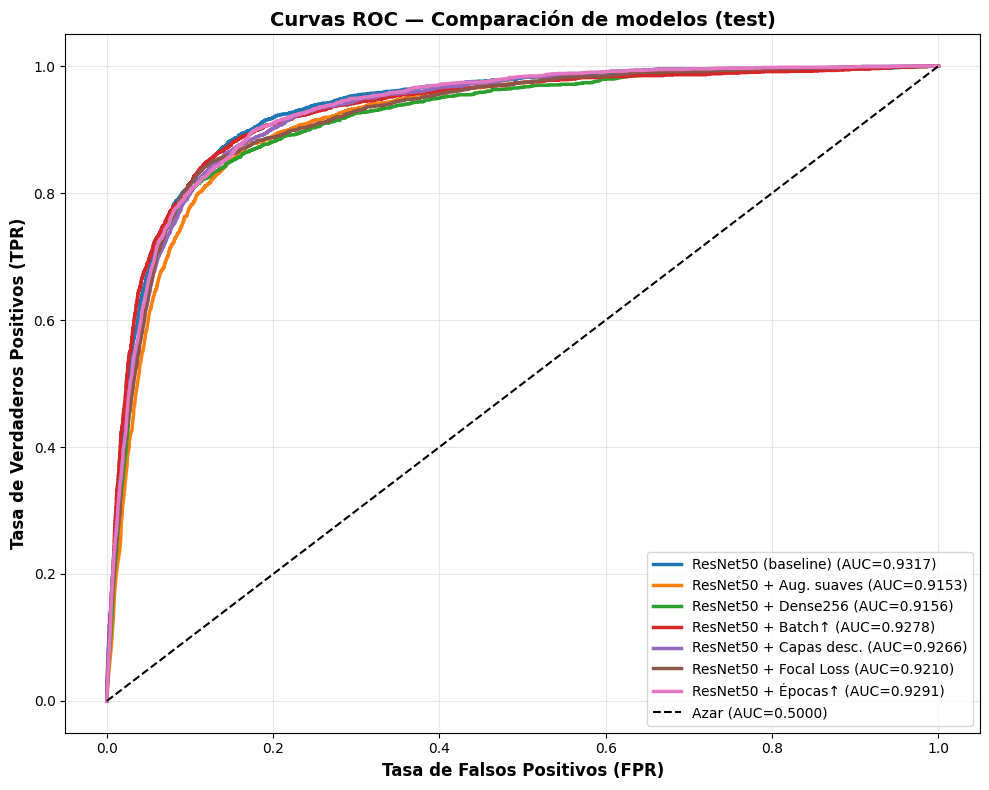


VALORES AUC (Área Bajo la Curva ROC)
🥇 ResNet50 (baseline)                 AUC = 0.9317
🥈 ResNet50 + Épocas↑                  AUC = 0.9291
🥉 ResNet50 + Batch↑                   AUC = 0.9278
   ResNet50 + Capas desc.              AUC = 0.9266
   ResNet50 + Focal Loss               AUC = 0.9210
   ResNet50 + Dense256                 AUC = 0.9156
   ResNet50 + Aug. suaves              AUC = 0.9153

Tabla D-prime (separabilidad de scores) por modelo y clase


,modelo,clase,d_prime,mu_pos,mu_neg
0,ResNet50 (baseline),Malignant (1),2.373075,0.786046,0.120304
1,ResNet50 + Aug. suaves,Malignant (1),2.138124,0.766148,0.127878
2,ResNet50 + Dense256,Malignant (1),2.179903,0.721742,0.116007
3,ResNet50 + Batch↑,Malignant (1),2.306237,0.788734,0.111052
4,ResNet50 + Capas desc.,Malignant (1),2.293974,0.792134,0.135602
5,ResNet50 + Focal Loss,Malignant (1),2.200222,0.531872,0.153379
6,ResNet50 + Épocas↑,Malignant (1),2.352038,0.815485,0.155306



RESUMEN DE VARIANTES EVALUADAS
• ResNet50 (baseline)
• ResNet50 + Aug. suaves
• ResNet50 + Dense256
• ResNet50 + Batch↑
• ResNet50 + Capas desc.
• ResNet50 + Focal Loss
• ResNet50 + Épocas↑


In [139]:
# Importaciones necesarias
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Diccionario para mapear nombres de modelos a descripciones
MODEL_VARIANTS = {
    'resnet50_20260110_001917-normal': 'ResNet50 (baseline)',
    'resnet50_20260112_032701-data.augmentation': 'ResNet50 + Aug. suaves',
    'resnet50_20260111_220602-dense256': 'ResNet50 + Dense256',
    'resnet50_20260103_235009-batchzise-mayor': 'ResNet50 + Batch↑',
    'resnet50_20260111_215331-unfreeze-max': 'ResNet50 + Capas desc.',
    'resnet50_20260112_035343-focal-loss': 'ResNet50 + Focal Loss',
    'resnet50_20260113_021021-mas-epocas': 'ResNet50 + Épocas↑',
}

def get_model_display_name(model_full_name):
    """
    Convierte el nombre completo del modelo a su versión descriptiva
    
    Ejemplo:
        'resnet50_20260112_032701-data.augmentation' -> 'ResNet50 + Aug. suaves'
    """
    # Buscar coincidencia exacta primero
    if model_full_name in MODEL_VARIANTS:
        return MODEL_VARIANTS[model_full_name]
    
    # Si no hay coincidencia exacta, intentar buscar por el sufijo descriptivo
    for key, value in MODEL_VARIANTS.items():
        if model_full_name.startswith(key.split('-')[0]):  # Coincidir por timestamp
            if key.endswith(model_full_name.split('-')[-1]):  # Coincidir por sufijo
                return value
    
    # Si no se encuentra, extraer el sufijo descriptivo
    if '-' in model_full_name:
        suffix = model_full_name.split('-', 1)[1]
        suffix_clean = suffix.replace('.', ' ').replace('-', ' ').title()
        return f"ResNet50 + {suffix_clean}"
    
    # Último recurso: devolver el nombre original
    return model_full_name

# Ejecución simplificada: matrices de confusión, D′, Classification Report y ROC
from sklearn.metrics import classification_report

split = 'test'  # Cambiar a 'validation' si se desea

all_dprime_rows = []
for model in selected_models:
    bundle = load_score_bundle(selected_comparison_folder, model, split)
    scores = bundle['scores']
    labels = bundle['labels']
    binary_sigmoid = bundle['binary_sigmoid']
    effective_classes = bundle['effective_classes']

    # Predicciones por modelo
    if effective_classes == 1 or binary_sigmoid:
        preds = (scores[:, 0] >= 0.5).astype(int)
        target_names = ['Benign', 'Malignant']
    else:
        preds = np.argmax(scores, axis=1)
        target_names = [f'Clase {k}' for k in range(scores.shape[1])]

    # Obtener nombre descriptivo del modelo
    model_display_name = get_model_display_name(model)
    
    # Classification Report
    print(f"\n{'='*70}")
    print(f"{model_display_name}")
    print(f"Classification Report ({split})")
    print('='*70)
    print(classification_report(labels, preds, target_names=target_names, digits=4))

    # D′ por clase para este modelo
    df_d = compute_dprime(scores, labels, effective_classes, binary_sigmoid)
    df_d['modelo'] = model_display_name  # Usar nombre descriptivo
    all_dprime_rows.append(df_d)

# ========== MODIFICAR FUNCIONES DE PLOTTING ==========

def plot_confusions_for_models_with_names(comparison_folder: str, models: list, split: str = 'test'):
    """Versión modificada que usa nombres descriptivos"""
    n = len(models)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]
    
    for ax, model in zip(axes, models):
        bundle = load_score_bundle(comparison_folder, model, split)
        scores = bundle['scores']
        labels = bundle['labels']
        binary_sigmoid = bundle['binary_sigmoid']
        effective_classes = bundle['effective_classes']
        
        # Obtener nombre descriptivo
        model_display_name = get_model_display_name(model)
        
        if effective_classes == 1 or binary_sigmoid:
            preds = (scores[:, 0] >= 0.5).astype(int)
            class_names = ['Benign (0)', 'Malignant (1)']
        else:
            preds = np.argmax(scores, axis=1)
            class_names = [f'Clase {k}' for k in range(scores.shape[1])]
        
        cm = confusion_matrix(labels, preds)
        row_sums = cm.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        cm_pct = (cm / row_sums) * 100.0
        
        annot = np.empty_like(cm, dtype=object)
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                annot[i, j] = f"{cm[i, j]}\n{cm_pct[i, j]:.1f}%"
        
        sns.heatmap(
            cm_pct,
            annot=annot,
            fmt="",
            cmap='Blues',
            cbar=False,
            ax=ax,
            xticklabels=class_names,
            yticklabels=class_names,
        )
        ax.set_title(model_display_name, fontsize=11, fontweight='bold')
        ax.set_xlabel('Predicción')
        ax.set_ylabel('Real')
        ax.set_xticklabels(class_names, rotation=0)
        ax.set_yticklabels(class_names, rotation=0)
    
    plt.tight_layout()
    plt.show()

def plot_roc_for_models_with_names(comparison_folder: str, models: list, split: str = 'test'):
    """Versión modificada que usa nombres descriptivos y muestra valores AUC"""
    plt.figure(figsize=(10, 8))
    
    auc_results = []  # Para almacenar los resultados
    
    for model in models:
        bundle = load_score_bundle(comparison_folder, model, split)
        scores = bundle['scores']
        labels = bundle['labels']
        binary_sigmoid = bundle['binary_sigmoid']
        effective_classes = bundle['effective_classes']
        
        # Obtener nombre descriptivo
        model_display_name = get_model_display_name(model)
        
        if effective_classes == 1 or binary_sigmoid:
            y_true = labels.astype(int)
            y_scores = scores[:, 0]
            
            fpr, tpr, _ = roc_curve(y_true, y_scores)
            auc_value = roc_auc_score(y_true, y_scores)
            
            plt.plot(fpr, tpr, linewidth=2.5, 
                    label=f'{model_display_name} (AUC={auc_value:.4f})')
            
            # Guardar resultado
            auc_results.append({
                'Modelo': model_display_name,
                'AUC': auc_value
            })
        else:
            # Multiclase: curva ROC promedio o por clase
            y_true_bin = label_binarize(labels, classes=np.arange(scores.shape[1]))
            
            if y_true_bin.shape[1] > 1:
                fpr_macro, tpr_macro, _ = roc_curve(y_true_bin.ravel(), scores.ravel())
                auc_macro = roc_auc_score(y_true_bin, scores, average='macro', multi_class='ovr')
            else:
                fpr_macro, tpr_macro, _ = roc_curve(y_true_bin, scores[:, 1])
                auc_macro = roc_auc_score(y_true_bin, scores[:, 1])
            
            plt.plot(fpr_macro, tpr_macro, linewidth=2.5,
                    label=f'{model_display_name} (AUC={auc_macro:.4f})')
            
            # Guardar resultado
            auc_results.append({
                'Modelo': model_display_name,
                'AUC': auc_macro
            })
    
    # Línea diagonal de referencia
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Azar (AUC=0.5000)')
    
    plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12, fontweight='bold')
    plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12, fontweight='bold')
    plt.title(f'Curvas ROC — Comparación de modelos ({split})', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Imprimir tabla de valores AUC
    df_auc = pd.DataFrame(auc_results)
    df_auc = df_auc.sort_values('AUC', ascending=False)
    
    print('\n' + '='*60)
    print('VALORES AUC (Área Bajo la Curva ROC)')
    print('='*60)
    for idx, row in df_auc.iterrows():
        ranking = '🥇' if idx == df_auc.index[0] else '🥈' if idx == df_auc.index[1] else '🥉' if idx == df_auc.index[2] else '  '
        print(f"{ranking} {row['Modelo']:<35} AUC = {row['AUC']:.4f}")
    print('='*60)
    
    return df_auc

# ========== EJECUTAR ANÁLISIS ==========

print("\n" + "╔" + "="*68 + "╗")
print("║" + " "*15 + "ANÁLISIS COMPARATIVO DE VARIANTES" + " "*20 + "║")
print("╚" + "="*68 + "╝")

# Matrices de confusión
print("\n📊 Generando matrices de confusión...")
plot_confusions_for_models_with_names(selected_comparison_folder, selected_models, split)

# Curvas ROC
print("\n📈 Generando curvas ROC...")
df_auc_results = plot_roc_for_models_with_names(selected_comparison_folder, selected_models, split)

# Tabla consolidada de D′
df_dprime_all = pd.concat(all_dprime_rows, ignore_index=True)
df_dprime_all = df_dprime_all[['modelo', 'clase', 'd_prime', 'mu_pos', 'mu_neg']]

print('\n' + '='*70)
print('Tabla D-prime (separabilidad de scores) por modelo y clase')
print('='*70)
display(df_dprime_all)

# ========== TABLA RESUMEN DE VARIANTES ==========
print('\n' + '='*70)
print('RESUMEN DE VARIANTES EVALUADAS')
print('='*70)
for model in selected_models:
    display_name = get_model_display_name(model)
    print(f"• {display_name}")
print('='*70)

In [140]:
# Utilidades: carga de scores desde CSVs
def load_score_bundle(comparison_folder: str, model: str, split: str = 'test'):
    """
    Carga scores desde archivos CSV y JSON.
    
    Args:
        comparison_folder: carpeta de comparación (ej: 'comparison', 'comparison_02')
        model: nombre del directorio del modelo
        split: 'test' o 'validation'
    
    Returns:
        dict con 'scores', 'labels', 'norm_scores', 'binary_sigmoid', 'effective_classes'
    """
    # Ruta base desde el directorio del notebook hacia outputs
    base_path = os.path.join('..', 'outputs', comparison_folder, model)
    csv_file = f'prediction_scores_{split}.csv'
    csv_path = os.path.join(base_path, csv_file)
    json_path = os.path.join(base_path, 'results.json')
    
    print(f"\n=== Cargando modelo: {model} ===")
    print(f"Buscando CSV en: {csv_path}")
    
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"No se encontró {csv_path}")
    
    # Cargar CSV con scores
    df = pd.read_csv(csv_path)
    labels = df['true_label'].values.astype(int)
    scores = df['predicted_score'].values.reshape(-1, 1)  # scores como columna
    
    print(f"✓ Datos cargados: {len(labels)} muestras")
    print(f"  - Distribución de clases: {np.bincount(labels)}")
    print(f"  - Rango de scores: [{scores.min():.4f}, {scores.max():.4f}]")
    
    # Cargar info del modelo desde JSON
    binary_sigmoid = True
    effective_classes = 1
    
    if os.path.exists(json_path):
        with open(json_path, 'r') as f:
            results = pd.read_json(f)
            model_config = results.get('model_config', {})
            effective_classes = model_config.get('num_classes', 1)
            binary_sigmoid = (effective_classes == 1)
            print(f"  - Configuración: {effective_classes} clase(s), sigmoid={binary_sigmoid}")
    
    # Los scores ya son probabilidades (sigmoid aplicado), así que norm_scores = scores
    norm_scores = scores.copy()
    
    return {
        'scores': scores,
        'labels': labels,
        'norm_scores': norm_scores,
        'binary_sigmoid': bool(binary_sigmoid),
        'effective_classes': int(effective_classes)
    }

def d_prime_from_scores(scores_vec: np.ndarray, labels_bin: np.ndarray):
    """Calcula d-prime (sensibilidad de detección)"""
    pos = scores_vec[labels_bin == 1]
    neg = scores_vec[labels_bin == 0]
    if pos.size == 0 or neg.size == 0:
        return np.nan, np.nan, np.nan
    mu_pos = float(np.mean(pos))
    mu_neg = float(np.mean(neg))
    std_pos = float(np.std(pos, ddof=1)) if pos.size > 1 else 0.0
    std_neg = float(np.std(neg, ddof=1)) if neg.size > 1 else 0.0
    # Pooled std (SDT convencional)
    pooled = np.sqrt(0.5 * (std_pos**2 + std_neg**2))
    if pooled == 0:
        return np.nan, mu_pos, mu_neg
    dprime = (mu_pos - mu_neg) / pooled
    return dprime, mu_pos, mu_neg

def compute_dprime(scores: np.ndarray, labels: np.ndarray, effective_classes: int, binary_sigmoid: bool):
    """Calcula d-prime para cada clase"""
    rows = []
    if effective_classes == 1 or binary_sigmoid:
        # Binario: usar columna 0 como positiva (clase 1) vs negativa (clase 0)
        labels_bin = labels.astype(int)
        d, mu_pos, mu_neg = d_prime_from_scores(scores[:, 0], labels_bin)
        rows.append({'clase': 'Malignant (1)', 'd_prime': d, 'mu_pos': mu_pos, 'mu_neg': mu_neg})
        print(f"  - d' = {d:.3f} (μ_maligno={mu_pos:.3f}, μ_benigno={mu_neg:.3f})")
    else:
        # Multiclase: one-vs-rest para cada clase
        for k in range(scores.shape[1]):
            labels_bin = (labels == k).astype(int)
            d, mu_pos, mu_neg = d_prime_from_scores(scores[:, k], labels_bin)
            rows.append({'clase': f'{k}', 'd_prime': d, 'mu_pos': mu_pos, 'mu_neg': mu_neg})
            print(f"  - Clase {k}: d' = {d:.3f}")
    
    df = pd.DataFrame(rows)
    return df

In [141]:
import numpy as np
from typing import List, Dict, Tuple, Optional

def _safe_div(n: float, d: float) -> float:
    return n / d if d != 0 else 0.0

def threshold_analysis(
    y_true: np.ndarray,
    y_score: np.ndarray,
    thresholds: Optional[np.ndarray] = None,
    pos_label: int = 1,
    criterion: str = "youden"
) -> Tuple[List[Dict[str, float]], float, Dict[str, float]]:
    """
    Analiza métricas de clasificación binaria a través de distintos umbrales.

    Parámetros:
      y_true: etiquetas reales (0/1).
      y_score: scores o probabilidades del modelo en [0,1].
      thresholds: array de umbrales a evaluar; si None usa np.linspace(0,1,101).
      pos_label: etiqueta positiva.
      criterion: 'youden' | 'f1' | 'accuracy' | 'balanced_accuracy' para seleccionar umbral óptimo.

    Retorna:
      metrics_list: lista de dicts con métricas por umbral.
      best_threshold: umbral óptimo según el criterio.
      best_metrics: dict de métricas del umbral óptimo.
    """
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    if thresholds is None:
        thresholds = np.linspace(0.0, 1.0, 101)
    else:
        thresholds = np.asarray(thresholds)

    metrics_list: List[Dict[str, float]] = []

    pos = pos_label
    neg = 1 - pos_label

    for t in thresholds:
        y_pred = (y_score >= t).astype(int)

        tp = int(np.sum((y_true == pos) & (y_pred == 1)))
        fp = int(np.sum((y_true == neg) & (y_pred == 1)))
        tn = int(np.sum((y_true == neg) & (y_pred == 0)))
        fn = int(np.sum((y_true == pos) & (y_pred == 0)))

        precision = _safe_div(tp, tp + fp)
        recall = _safe_div(tp, tp + fn)             # sensibilidad
        specificity = _safe_div(tn, tn + fp)
        accuracy = _safe_div(tp + tn, tp + tn + fp + fn)
        f1 = _safe_div(2 * precision * recall, precision + recall)
        balanced_accuracy = (recall + specificity) / 2.0
        youden_j = recall + specificity - 1.0

        mcc_num = tp * tn - fp * fn
        mcc_den = np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
        mcc = _safe_div(mcc_num, mcc_den)

        metrics_list.append({
            "threshold": float(t),
            "tp": tp, "fp": fp, "tn": tn, "fn": fn,
            "precision": precision,
            "recall": recall,
            "specificity": specificity,
            "accuracy": accuracy,
            "f1": f1,
            "balanced_accuracy": balanced_accuracy,
            "youden_j": youden_j,
            "mcc": mcc,
        })

    # Selección de umbral óptimo
    key_map = {
        "youden": "youden_j",
        "f1": "f1",
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
    }
    metric_key = key_map.get(criterion, "youden_j")

    values = np.array([m[metric_key] for m in metrics_list])
    best_idx = int(np.argmax(values))
    best_metrics = metrics_list[best_idx]
    best_threshold = best_metrics["threshold"]

    return metrics_list, best_threshold, best_metrics

# Ejemplo de uso:
# metrics, t_opt, best = threshold_analysis(y_true, y_prob, criterion="youden")
# print("Umbral óptimo:", t_opt)
# print("Métricas en óptimo:", best)

In [142]:
# Confusión: matrices por modelo, mostradas juntas
from sklearn.metrics import accuracy_score

def plot_confusions_for_models(comparison_folder: str, models: list, split: str = 'test'):
    n = len(models)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]

    for ax, model in zip(axes, models):
        bundle = load_score_bundle(comparison_folder, model, split)
        scores = bundle['scores']
        labels = bundle['labels']
        binary_sigmoid = bundle['binary_sigmoid']
        effective_classes = bundle['effective_classes']

        if effective_classes == 1 or binary_sigmoid:
            preds = (scores[:, 0] >= 0.5).astype(int)
        else:
            preds = np.argmax(scores, axis=1)

        cm = confusion_matrix(labels, preds)
        row_sums = cm.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        cm_pct = (cm / row_sums) * 100.0

        # Etiquetas de ejes
        if effective_classes == 1 or binary_sigmoid:
            class_names = ['Benign (0)', 'Malignant (1)']
        else:
            class_names = [f'Clase {k}' for k in range(cm.shape[0])]

        # Anotaciones: conteos y porcentajes
        annot = np.empty_like(cm, dtype=object)
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                annot[i, j] = f"{cm[i, j]}\n{cm_pct[i, j]:.1f}%"

        sns.heatmap(
            cm_pct,
            annot=annot,
            fmt="",
            cmap='Blues',
            cbar=False,
            ax=ax,
            xticklabels=class_names,
            yticklabels=class_names,
        )

        # Extraer nombre del modelo del directorio
        model_name = model.split('_')[0]
        ax.set_title(f'{model_name}\nAcc: {accuracy_score(labels, preds):.4f}')
        ax.set_xlabel('Predicción')
        ax.set_ylabel('Real')
        ax.set_xticklabels(class_names, rotation=0)
        ax.set_yticklabels(class_names, rotation=0)

    plt.tight_layout()
    plt.show()


In [143]:
# Curvas ROC: una figura con todos los modelos
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

def _stable_softmax(x: np.ndarray, axis: int = 1) -> np.ndarray:
    x_max = np.max(x, axis=axis, keepdims=True)
    e = np.exp(x - x_max)
    return e / np.sum(e, axis=axis, keepdims=True)

def _sigmoid(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-x))

def plot_roc_for_models(comparison_folder: str, models: list, split: str = 'test'):
    plt.figure(figsize=(8, 6))
    for model in models:
        bundle = load_score_bundle(comparison_folder, model, split)
        scores = bundle['scores']
        labels = bundle['labels']
        norm_scores = bundle['norm_scores']
        binary_sigmoid = bundle['binary_sigmoid']
        effective_classes = bundle['effective_classes']
        
        # Los scores ya son probabilidades
        probs = norm_scores
        
        # Binario vs multiclase
        if effective_classes == 1 or binary_sigmoid:
            y_true = labels.astype(int)
            y_score = probs[:, 0] if probs.ndim == 2 else probs
            # Validar presencia de ambas clases
            if len(np.unique(y_true)) < 2:
                print(f"Aviso: {model} no tiene ambas clases presentes. Se omite ROC.")
                continue
            fpr, tpr, _ = roc_curve(y_true, y_score)
            auc_val = auc(fpr, tpr)
            model_name = model.split('_')[0]
            plt.plot(fpr, tpr, lw=2, label=f"{model_name} (AUC={auc_val:.3f})")
        else:
            n_classes = scores.shape[1]
            classes = list(range(n_classes))
            y_true_bin = label_binarize(labels, classes=classes)
            # Calcular macro-promedio
            fpr_grid = np.linspace(0, 1, 101)
            tprs = []
            valid = 0
            for k in range(n_classes):
                yk = y_true_bin[:, k]
                if yk.sum() == 0 or (yk.size - yk.sum()) == 0:
                    continue
                fpr_k, tpr_k, _ = roc_curve(yk, probs[:, k])
                tpr_interp = np.interp(fpr_grid, fpr_k, tpr_k)
                tpr_interp[0] = 0.0
                tprs.append(tpr_interp)
                valid += 1
            if valid == 0:
                print(f"Aviso: {model} no tiene clases suficientes para ROC multiclase. Se omite.")
                continue
            mean_tpr = np.mean(np.vstack(tprs), axis=0)
            mean_tpr[-1] = 1.0
            auc_val = auc(fpr_grid, mean_tpr)
            model_name = model.split('_')[0]
            plt.plot(fpr_grid, mean_tpr, lw=2, label=f"{model_name} (macro AUC={auc_val:.3f})")
    
    plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Azar')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('FPR (1 - Especificidad)')
    plt.ylabel('TPR (Sensibilidad)')
    plt.title(f'Curvas ROC - {comparison_folder} ({split})')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()



=== Cargando modelo: resnet50_20260110_001917-normal ===
Buscando CSV en: ../outputs/comparision_resnet/resnet50_20260110_001917-normal/prediction_scores_test.csv
✓ Datos cargados: 17125 muestras
  - Distribución de clases: [15067  2058]
  - Rango de scores: [0.0000, 1.0000]
  - Configuración: 1 clase(s), sigmoid=True

resnet50_20260110_001917-normal
Classification Report (test)
              precision    recall  f1-score   support

      Benign     0.9727    0.8998    0.9348     15067
   Malignant     0.5264    0.8149    0.6396      2058

    accuracy                         0.8896     17125
   macro avg     0.7495    0.8574    0.7872     17125
weighted avg     0.9190    0.8896    0.8994     17125

  - d' = 2.373 (μ_maligno=0.786, μ_benigno=0.120)

=== Cargando modelo: resnet50_20260112_032701-data.augmentation ===
Buscando CSV en: ../outputs/comparision_resnet/resnet50_20260112_032701-data.augmentation/prediction_scores_test.csv
✓ Datos cargados: 17125 muestras
  - Distribución de c

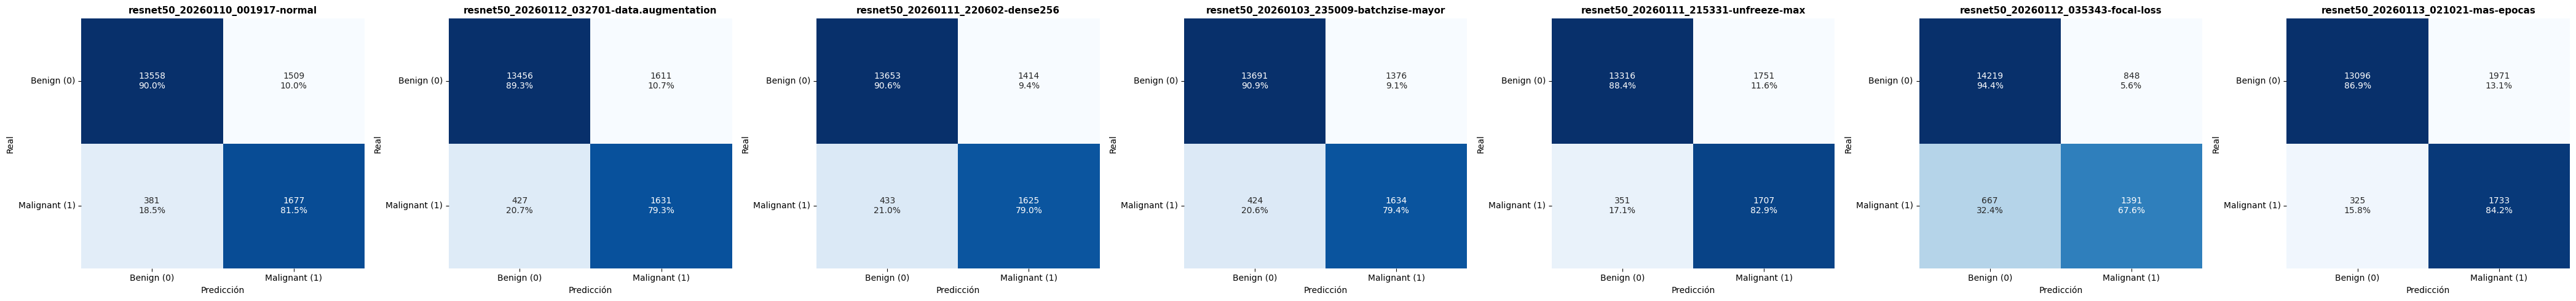


📈 Generando curvas ROC...

=== Cargando modelo: resnet50_20260110_001917-normal ===
Buscando CSV en: ../outputs/comparision_resnet/resnet50_20260110_001917-normal/prediction_scores_test.csv
✓ Datos cargados: 17125 muestras
  - Distribución de clases: [15067  2058]
  - Rango de scores: [0.0000, 1.0000]
  - Configuración: 1 clase(s), sigmoid=True

=== Cargando modelo: resnet50_20260112_032701-data.augmentation ===
Buscando CSV en: ../outputs/comparision_resnet/resnet50_20260112_032701-data.augmentation/prediction_scores_test.csv
✓ Datos cargados: 17125 muestras
  - Distribución de clases: [15067  2058]
  - Rango de scores: [0.0000, 1.0000]
  - Configuración: 1 clase(s), sigmoid=True

=== Cargando modelo: resnet50_20260111_220602-dense256 ===
Buscando CSV en: ../outputs/comparision_resnet/resnet50_20260111_220602-dense256/prediction_scores_test.csv
✓ Datos cargados: 17125 muestras
  - Distribución de clases: [15067  2058]
  - Rango de scores: [0.0000, 1.0000]
  - Configuración: 1 clase(s

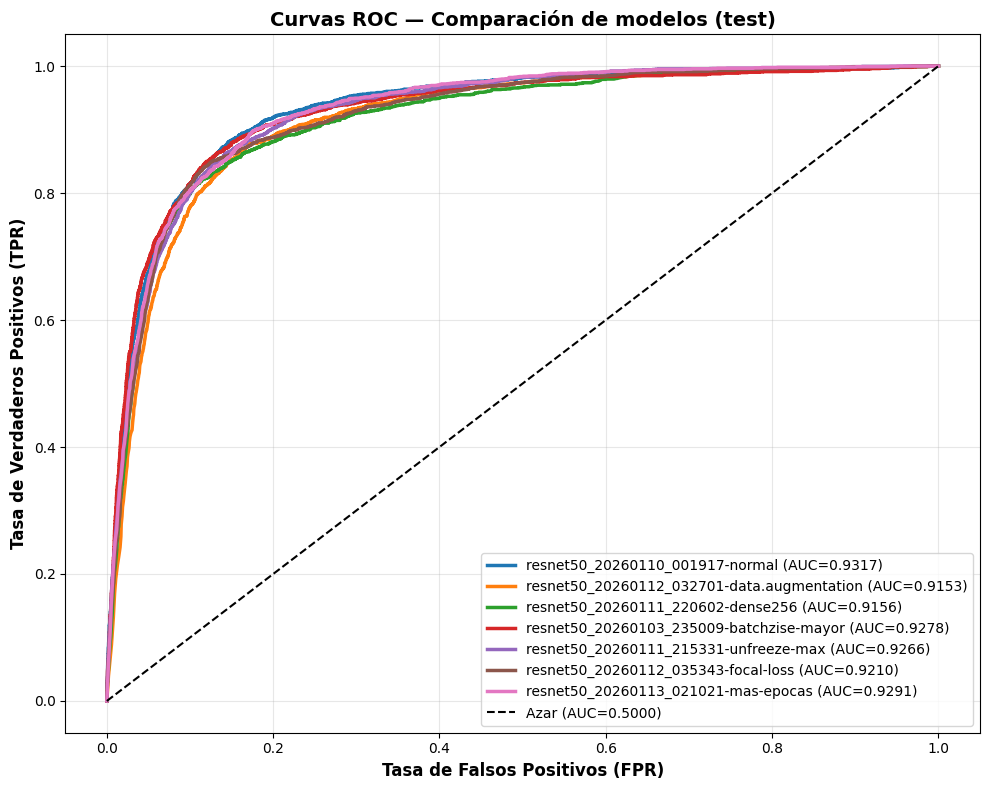


Tabla D-prime (separabilidad de scores) por modelo y clase


,modelo,clase,d_prime,mu_pos,mu_neg
0,resnet50_20260110_001917-normal,Malignant (1),2.373075,0.786046,0.120304
1,resnet50_20260112_032701-data.augmentation,Malignant (1),2.138124,0.766148,0.127878
2,resnet50_20260111_220602-dense256,Malignant (1),2.179903,0.721742,0.116007
3,resnet50_20260103_235009-batchzise-mayor,Malignant (1),2.306237,0.788734,0.111052
4,resnet50_20260111_215331-unfreeze-max,Malignant (1),2.293974,0.792134,0.135602
5,resnet50_20260112_035343-focal-loss,Malignant (1),2.200222,0.531872,0.153379
6,resnet50_20260113_021021-mas-epocas,Malignant (1),2.352038,0.815485,0.155306



RESUMEN DE VARIANTES EVALUADAS
• resnet50_20260110_001917-normal
• resnet50_20260112_032701-data.augmentation
• resnet50_20260111_220602-dense256
• resnet50_20260103_235009-batchzise-mayor
• resnet50_20260111_215331-unfreeze-max
• resnet50_20260112_035343-focal-loss
• resnet50_20260113_021021-mas-epocas


In [144]:
# Importaciones necesarias
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Diccionario para mapear nombres de modelos a descripciones
MODEL_VARIANTS = {
    'ResNet50_v1': 'ResNet50 (baseline)',
    'ResNet50_v2': 'ResNet50 + Aug. suaves',
    'ResNet50_v3': 'ResNet50 + Cabezal mod.',
    'ResNet50_v4': 'ResNet50 + Batch↑',
    'ResNet50_v5': 'ResNet50 + Capas desc.',
    'ResNet50_v6': 'ResNet50 + Focal Loss',
    'ResNet50_v7': 'ResNet50 + Épocas↑',
    # Agrega más variantes según tu nomenclatura
}

def get_model_display_name(model_full_name):
    """
    Convierte el nombre completo del modelo a su versión descriptiva
    
    Ejemplo:
        'ResNet50_v2_20240115' -> 'ResNet50 + Aug. suaves'
    """
    # Extraer el identificador base (ej: ResNet50_v2)
    parts = model_full_name.split('_')
    if len(parts) >= 2:
        base_name = f"{parts[0]}_{parts[1]}"  # Ej: ResNet50_v2
    else:
        base_name = parts[0]
    
    # Buscar en el diccionario
    return MODEL_VARIANTS.get(base_name, model_full_name)

# Ejecución simplificada: matrices de confusión, D′, Classification Report y ROC
from sklearn.metrics import classification_report

split = 'test'  # Cambiar a 'validation' si se desea

all_dprime_rows = []
for model in selected_models:
    bundle = load_score_bundle(selected_comparison_folder, model, split)
    scores = bundle['scores']
    labels = bundle['labels']
    binary_sigmoid = bundle['binary_sigmoid']
    effective_classes = bundle['effective_classes']

    # Predicciones por modelo
    if effective_classes == 1 or binary_sigmoid:
        preds = (scores[:, 0] >= 0.5).astype(int)
        target_names = ['Benign', 'Malignant']
    else:
        preds = np.argmax(scores, axis=1)
        target_names = [f'Clase {k}' for k in range(scores.shape[1])]

    # Obtener nombre descriptivo del modelo
    model_display_name = get_model_display_name(model)
    
    # Classification Report
    print(f"\n{'='*70}")
    print(f"{model_display_name}")
    print(f"Classification Report ({split})")
    print('='*70)
    print(classification_report(labels, preds, target_names=target_names, digits=4))

    # D′ por clase para este modelo
    df_d = compute_dprime(scores, labels, effective_classes, binary_sigmoid)
    df_d['modelo'] = model_display_name  # Usar nombre descriptivo
    all_dprime_rows.append(df_d)

# ========== MODIFICAR FUNCIONES DE PLOTTING ==========

def plot_confusions_for_models_with_names(comparison_folder: str, models: list, split: str = 'test'):
    """Versión modificada que usa nombres descriptivos"""
    n = len(models)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]
    
    for ax, model in zip(axes, models):
        bundle = load_score_bundle(comparison_folder, model, split)
        scores = bundle['scores']
        labels = bundle['labels']
        binary_sigmoid = bundle['binary_sigmoid']
        effective_classes = bundle['effective_classes']
        
        # Obtener nombre descriptivo
        model_display_name = get_model_display_name(model)
        
        if effective_classes == 1 or binary_sigmoid:
            preds = (scores[:, 0] >= 0.5).astype(int)
            class_names = ['Benign (0)', 'Malignant (1)']
        else:
            preds = np.argmax(scores, axis=1)
            class_names = [f'Clase {k}' for k in range(scores.shape[1])]
        
        cm = confusion_matrix(labels, preds)
        row_sums = cm.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        cm_pct = (cm / row_sums) * 100.0
        
        annot = np.empty_like(cm, dtype=object)
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                annot[i, j] = f"{cm[i, j]}\n{cm_pct[i, j]:.1f}%"
        
        sns.heatmap(
            cm_pct,
            annot=annot,
            fmt="",
            cmap='Blues',
            cbar=False,
            ax=ax,
            xticklabels=class_names,
            yticklabels=class_names,
        )
        ax.set_title(model_display_name, fontsize=11, fontweight='bold')
        ax.set_xlabel('Predicción')
        ax.set_ylabel('Real')
        ax.set_xticklabels(class_names, rotation=0)
        ax.set_yticklabels(class_names, rotation=0)
    
    plt.tight_layout()
    plt.show()

def plot_roc_for_models_with_names(comparison_folder: str, models: list, split: str = 'test'):
    """Versión modificada que usa nombres descriptivos"""
    plt.figure(figsize=(10, 8))
    
    for model in models:
        bundle = load_score_bundle(comparison_folder, model, split)
        scores = bundle['scores']
        labels = bundle['labels']
        binary_sigmoid = bundle['binary_sigmoid']
        effective_classes = bundle['effective_classes']
        
        # Obtener nombre descriptivo
        model_display_name = get_model_display_name(model)
        
        if effective_classes == 1 or binary_sigmoid:
            y_true = labels.astype(int)
            y_scores = scores[:, 0]
            
            fpr, tpr, _ = roc_curve(y_true, y_scores)
            auc_value = roc_auc_score(y_true, y_scores)
            
            plt.plot(fpr, tpr, linewidth=2.5, 
                    label=f'{model_display_name} (AUC={auc_value:.4f})')
        else:
            # Multiclase: curva ROC promedio o por clase
            y_true_bin = label_binarize(labels, classes=np.arange(scores.shape[1]))
            
            if y_true_bin.shape[1] > 1:
                fpr_macro, tpr_macro, _ = roc_curve(y_true_bin.ravel(), scores.ravel())
                auc_macro = roc_auc_score(y_true_bin, scores, average='macro', multi_class='ovr')
            else:
                fpr_macro, tpr_macro, _ = roc_curve(y_true_bin, scores[:, 1])
                auc_macro = roc_auc_score(y_true_bin, scores[:, 1])
            
            plt.plot(fpr_macro, tpr_macro, linewidth=2.5,
                    label=f'{model_display_name} (AUC={auc_macro:.4f})')
    
    # Línea diagonal de referencia
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Azar (AUC=0.5000)')
    
    plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12, fontweight='bold')
    plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12, fontweight='bold')
    plt.title(f'Curvas ROC — Comparación de modelos ({split})', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ========== EJECUTAR ANÁLISIS ==========

print("\n" + "╔" + "="*68 + "╗")
print("║" + " "*15 + "ANÁLISIS COMPARATIVO DE VARIANTES" + " "*20 + "║")
print("╚" + "="*68 + "╝")

# Matrices de confusión
print("\n📊 Generando matrices de confusión...")
plot_confusions_for_models_with_names(selected_comparison_folder, selected_models, split)

# Curvas ROC
print("\n📈 Generando curvas ROC...")
plot_roc_for_models_with_names(selected_comparison_folder, selected_models, split)

# Tabla consolidada de D′
df_dprime_all = pd.concat(all_dprime_rows, ignore_index=True)
df_dprime_all = df_dprime_all[['modelo', 'clase', 'd_prime', 'mu_pos', 'mu_neg']]

print('\n' + '='*70)
print('Tabla D-prime (separabilidad de scores) por modelo y clase')
print('='*70)
display(df_dprime_all)

# ========== TABLA RESUMEN DE VARIANTES ==========
print('\n' + '='*70)
print('RESUMEN DE VARIANTES EVALUADAS')
print('='*70)
for model in selected_models:
    display_name = get_model_display_name(model)
    print(f"• {display_name}")
print('='*70)


## Visualización del umbral óptimo por modelo
Este apartado calcula el umbral óptimo (criterio de Youden por defecto) para cada modelo seleccionado y grafica las métricas en función del umbral, indicando el óptimo con una línea vertical.


=== Cargando modelo: resnet50_20260110_001917-normal ===
Buscando CSV en: ../outputs/comparision_resnet/resnet50_20260110_001917-normal/prediction_scores_test.csv
✓ Datos cargados: 17125 muestras
  - Distribución de clases: [15067  2058]
  - Rango de scores: [0.0000, 1.0000]
  - Configuración: 1 clase(s), sigmoid=True

resnet50 — Umbral óptimo (Youden): 0.280
{'threshold': '0.2800', 'tp': 1811, 'fp': 2204, 'tn': 12863, 'fn': 247, 'precision': '0.4511', 'recall': '0.8800', 'specificity': '0.8537', 'accuracy': '0.8569', 'f1': '0.5964', 'balanced_accuracy': '0.8669', 'youden_j': '0.7337', 'mcc': '0.5631'}


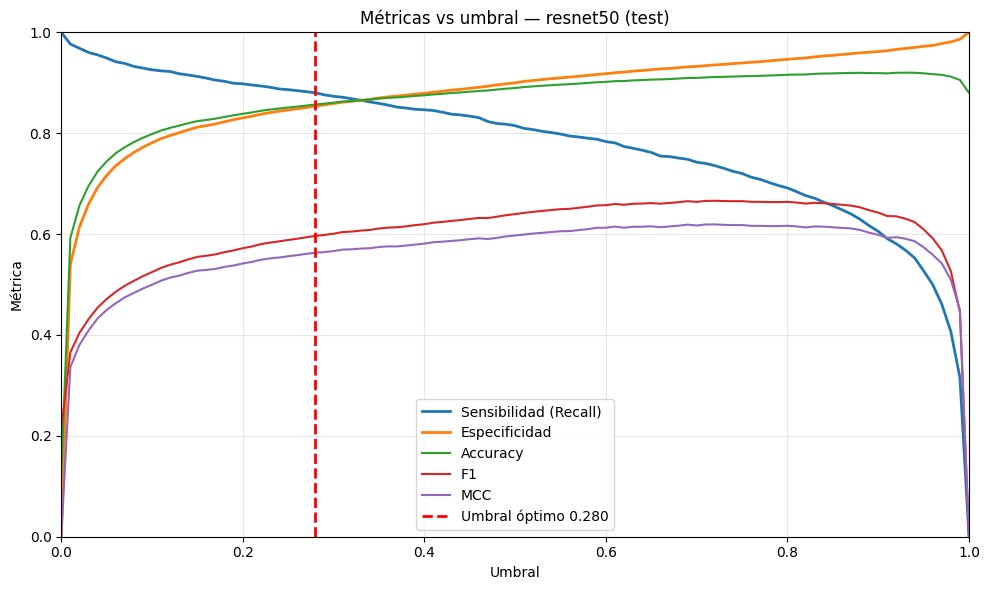


=== Cargando modelo: resnet50_20260112_032701-data.augmentation ===
Buscando CSV en: ../outputs/comparision_resnet/resnet50_20260112_032701-data.augmentation/prediction_scores_test.csv
✓ Datos cargados: 17125 muestras
  - Distribución de clases: [15067  2058]
  - Rango de scores: [0.0000, 1.0000]
  - Configuración: 1 clase(s), sigmoid=True

resnet50 — Umbral óptimo (Youden): 0.210
{'threshold': '0.2100', 'tp': 1805, 'fp': 2589, 'tn': 12478, 'fn': 253, 'precision': '0.4108', 'recall': '0.8771', 'specificity': '0.8282', 'accuracy': '0.8340', 'f1': '0.5595', 'balanced_accuracy': '0.8526', 'youden_j': '0.7052', 'mcc': '0.5251'}


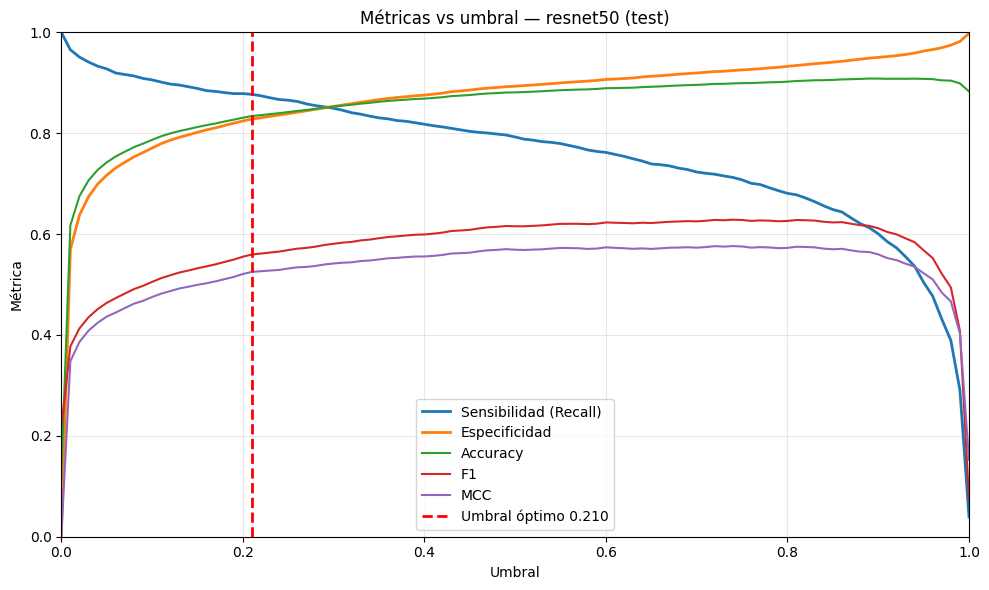


=== Cargando modelo: resnet50_20260111_220602-dense256 ===
Buscando CSV en: ../outputs/comparision_resnet/resnet50_20260111_220602-dense256/prediction_scores_test.csv
✓ Datos cargados: 17125 muestras
  - Distribución de clases: [15067  2058]
  - Rango de scores: [0.0000, 1.0000]
  - Configuración: 1 clase(s), sigmoid=True

resnet50 — Umbral óptimo (Youden): 0.400
{'threshold': '0.4000', 'tp': 1692, 'fp': 1748, 'tn': 13319, 'fn': 366, 'precision': '0.4919', 'recall': '0.8222', 'specificity': '0.8840', 'accuracy': '0.8766', 'f1': '0.6155', 'balanced_accuracy': '0.8531', 'youden_j': '0.7061', 'mcc': '0.5731'}


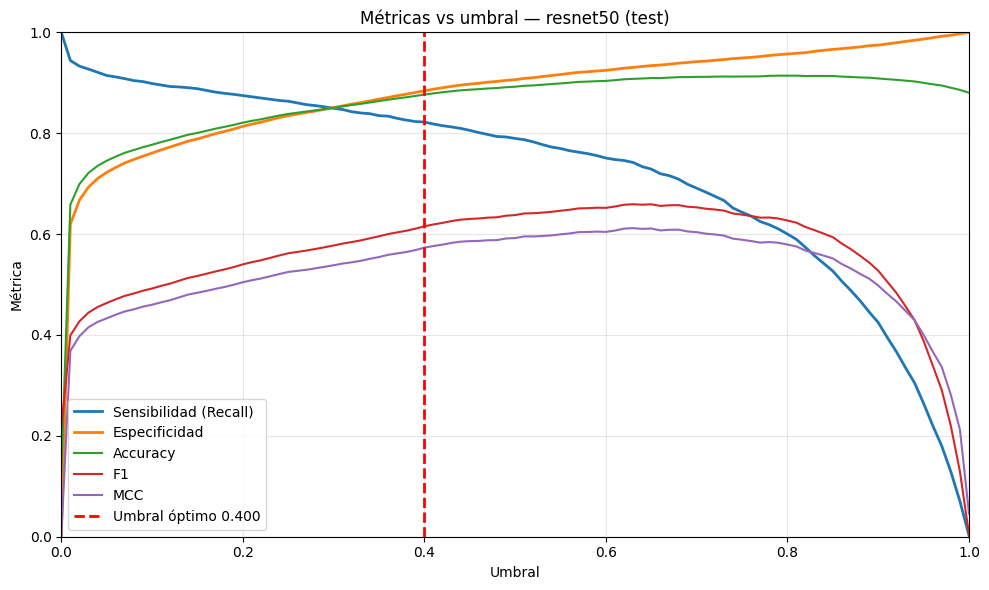


=== Cargando modelo: resnet50_20260103_235009-batchzise-mayor ===
Buscando CSV en: ../outputs/comparision_resnet/resnet50_20260103_235009-batchzise-mayor/prediction_scores_test.csv
✓ Datos cargados: 17125 muestras
  - Distribución de clases: [15067  2058]
  - Rango de scores: [0.0000, 1.0000]
  - Configuración: 1 clase(s), sigmoid=True

resnet50 — Umbral óptimo (Youden): 0.240
{'threshold': '0.2400', 'tp': 1775, 'fp': 1994, 'tn': 13073, 'fn': 283, 'precision': '0.4709', 'recall': '0.8625', 'specificity': '0.8677', 'accuracy': '0.8670', 'f1': '0.6092', 'balanced_accuracy': '0.8651', 'youden_j': '0.7301', 'mcc': '0.5731'}


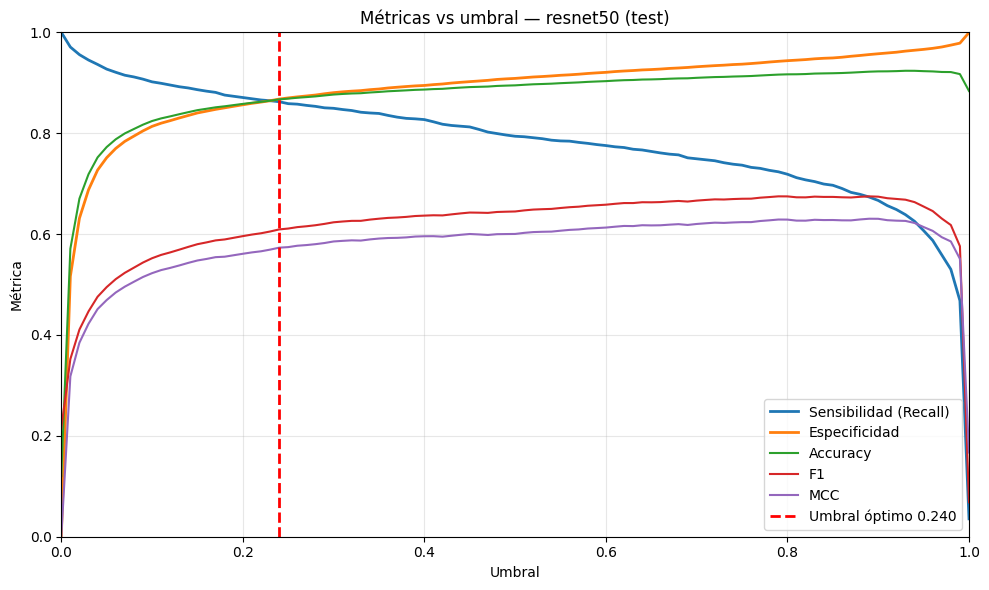


=== Cargando modelo: resnet50_20260111_215331-unfreeze-max ===
Buscando CSV en: ../outputs/comparision_resnet/resnet50_20260111_215331-unfreeze-max/prediction_scores_test.csv
✓ Datos cargados: 17125 muestras
  - Distribución de clases: [15067  2058]
  - Rango de scores: [0.0000, 1.0000]
  - Configuración: 1 clase(s), sigmoid=True

resnet50 — Umbral óptimo (Youden): 0.370
{'threshold': '0.3700', 'tp': 1773, 'fp': 2136, 'tn': 12931, 'fn': 285, 'precision': '0.4536', 'recall': '0.8615', 'specificity': '0.8582', 'accuracy': '0.8586', 'f1': '0.5943', 'balanced_accuracy': '0.8599', 'youden_j': '0.7197', 'mcc': '0.5576'}


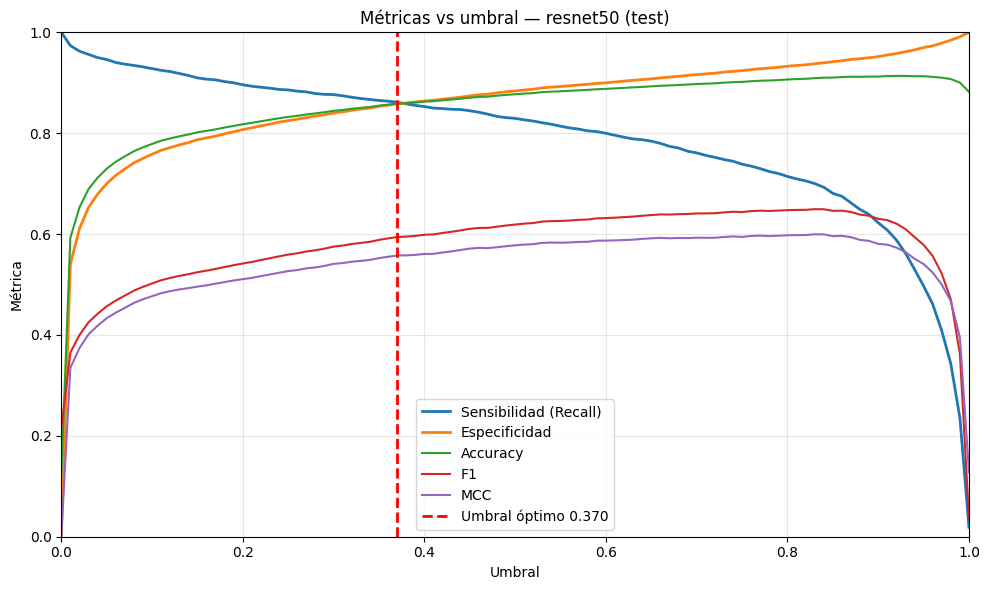


=== Cargando modelo: resnet50_20260112_035343-focal-loss ===
Buscando CSV en: ../outputs/comparision_resnet/resnet50_20260112_035343-focal-loss/prediction_scores_test.csv
✓ Datos cargados: 17125 muestras
  - Distribución de clases: [15067  2058]
  - Rango de scores: [0.0001, 0.9300]
  - Configuración: 1 clase(s), sigmoid=True

resnet50 — Umbral óptimo (Youden): 0.400
{'threshold': '0.4000', 'tp': 1739, 'fp': 1848, 'tn': 13219, 'fn': 319, 'precision': '0.4848', 'recall': '0.8450', 'specificity': '0.8773', 'accuracy': '0.8735', 'f1': '0.6161', 'balanced_accuracy': '0.8612', 'youden_j': '0.7223', 'mcc': '0.5772'}


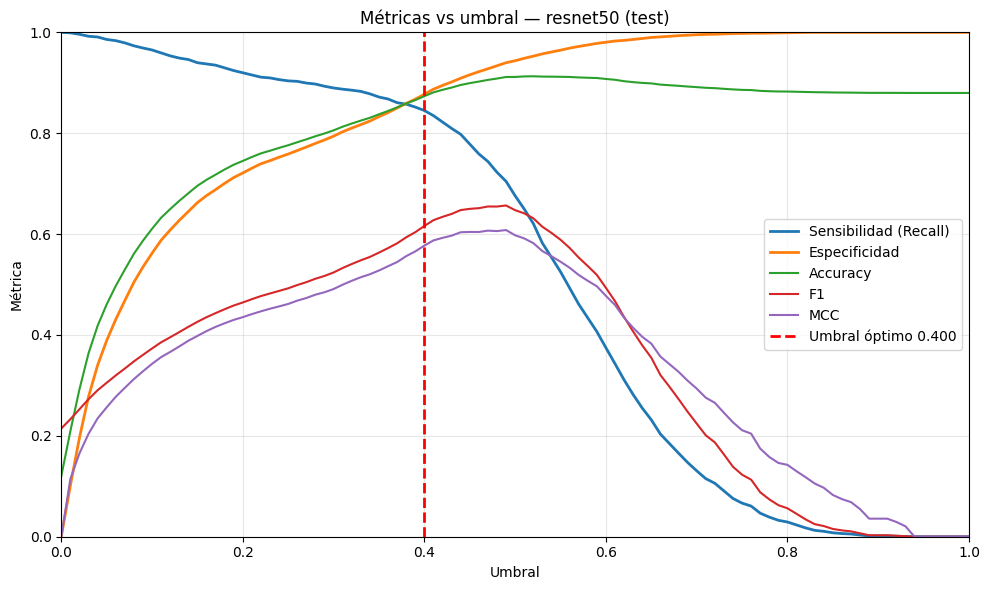


=== Cargando modelo: resnet50_20260113_021021-mas-epocas ===
Buscando CSV en: ../outputs/comparision_resnet/resnet50_20260113_021021-mas-epocas/prediction_scores_test.csv
✓ Datos cargados: 17125 muestras
  - Distribución de clases: [15067  2058]
  - Rango de scores: [0.0000, 1.0000]
  - Configuración: 1 clase(s), sigmoid=True

resnet50 — Umbral óptimo (Youden): 0.310
{'threshold': '0.3100', 'tp': 1844, 'fp': 2635, 'tn': 12432, 'fn': 214, 'precision': '0.4117', 'recall': '0.8960', 'specificity': '0.8251', 'accuracy': '0.8336', 'f1': '0.5642', 'balanced_accuracy': '0.8606', 'youden_j': '0.7211', 'mcc': '0.5336'}


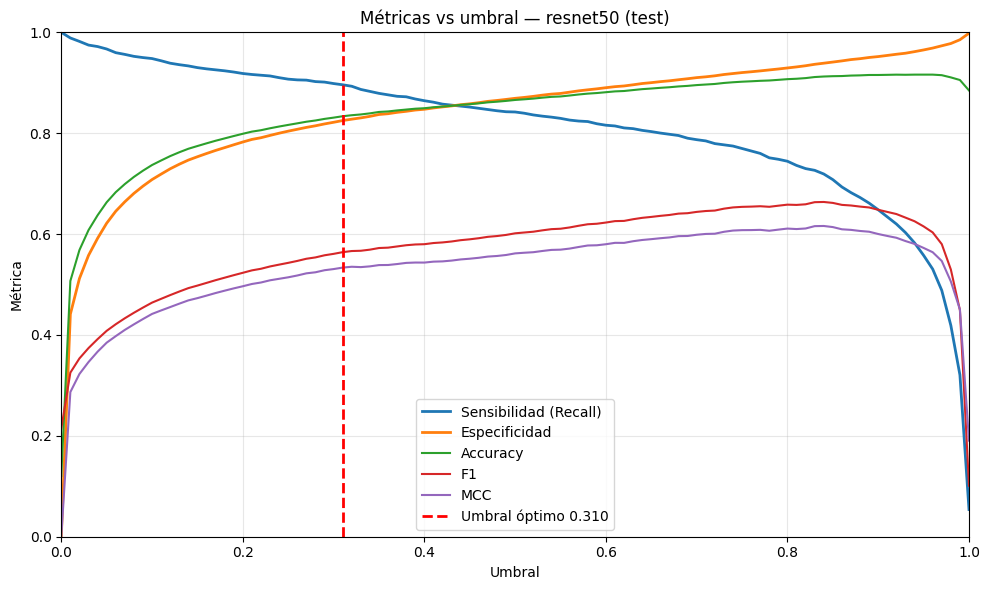

In [145]:
# Cálculo y visualización del umbral óptimo por modelo
def _ensure_binary_probs(scores: np.ndarray, norm_scores: np.ndarray, binary_sigmoid: bool, effective_classes: int) -> np.ndarray:
    """Genera probabilidades binarias en [0,1] para la clase positiva"""
    if effective_classes == 1 or binary_sigmoid:
        # Ya son probabilidades sigmoid
        return norm_scores[:, 0] if norm_scores.ndim == 2 else norm_scores
    else:
        # Multiclase: opción por defecto clase 1 como positiva (one-vs-rest)
        return norm_scores[:, 1]

split = 'test'  # Cambiar a 'validation' si se desea

for model in selected_models:
    bundle = load_score_bundle(selected_comparison_folder, model, split)
    scores = bundle['scores']
    labels = bundle['labels']
    norm_scores = bundle['norm_scores']
    binary_sigmoid = bundle['binary_sigmoid']
    effective_classes = bundle['effective_classes']
    
    # Binarización de etiquetas para análisis de umbral
    if effective_classes == 1 or binary_sigmoid:
        y_true = labels.astype(int)
    else:
        y_true = (labels == 1).astype(int)  # one-vs-rest para clase 1
    
    y_prob = _ensure_binary_probs(scores, norm_scores, binary_sigmoid, effective_classes)
    
    metrics_list, t_opt, best = threshold_analysis(y_true, y_prob, criterion="youden")
    
    model_name = model.split('_')[0]
    print(f"\n{'='*60}")
    print(f"{model_name} — Umbral óptimo (Youden): {t_opt:.3f}")
    print('='*60)
    print({k: (f"{v:.4f}" if isinstance(v, float) else v) for k, v in best.items()})
    
    # Visualización de métricas vs umbral
    thr = np.array([m['threshold'] for m in metrics_list])
    recall = np.array([m['recall'] for m in metrics_list])
    specificity = np.array([m['specificity'] for m in metrics_list])
    accuracy = np.array([m['accuracy'] for m in metrics_list])
    f1 = np.array([m['f1'] for m in metrics_list])
    mcc = np.array([m['mcc'] for m in metrics_list])
    
    plt.figure(figsize=(10, 6))
    plt.plot(thr, recall, label='Sensibilidad (Recall)', lw=2)
    plt.plot(thr, specificity, label='Especificidad', lw=2)
    plt.plot(thr, accuracy, label='Accuracy', lw=1.5)
    plt.plot(thr, f1, label='F1', lw=1.5)
    plt.plot(thr, mcc, label='MCC', lw=1.5)
    plt.axvline(t_opt, color='red', ls='--', lw=2, label=f"Umbral óptimo {t_opt:.3f}")
    plt.xlim(0.0, 1.0)
    plt.ylim(0.0, 1.0)
    plt.xlabel('Umbral')
    plt.ylabel('Métrica')
    plt.title(f'Métricas vs umbral — {model_name} ({split})')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## Matrices de confusión con umbrales óptimos
Calcula el umbral óptimo por modelo (criterio seleccionable) y muestra las matrices de confusión usando esos umbrales.

Criterio de umbral seleccionado: youden
Split de datos: test

=== Cargando modelo: resnet50_20260110_001917-normal ===
Buscando CSV en: ../outputs/comparision_resnet/resnet50_20260110_001917-normal/prediction_scores_test.csv
✓ Datos cargados: 17125 muestras
  - Distribución de clases: [15067  2058]
  - Rango de scores: [0.0000, 1.0000]
  - Configuración: 1 clase(s), sigmoid=True

resnet50 — Classification Report (umbral óptimo=0.280)
              precision    recall  f1-score   support

      Benign     0.9812    0.8537    0.9130     15067
   Malignant     0.4511    0.8800    0.5964      2058

    accuracy                         0.8569     17125
   macro avg     0.7161    0.8669    0.7547     17125
weighted avg     0.9175    0.8569    0.8750     17125


=== Cargando modelo: resnet50_20260112_032701-data.augmentation ===
Buscando CSV en: ../outputs/comparision_resnet/resnet50_20260112_032701-data.augmentation/prediction_scores_test.csv
✓ Datos cargados: 17125 muestras
  - Distribución

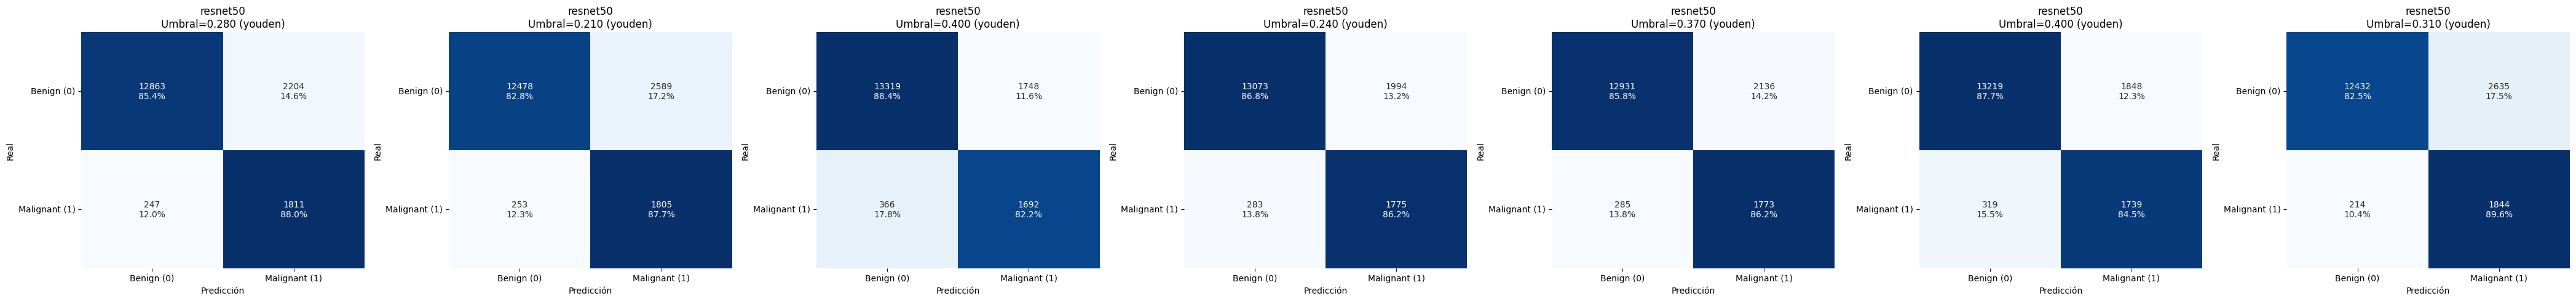

: 

In [ ]:
# Matrices de confusión con umbrales óptimos
opt_criterion = "youden"  # opciones: "youden", "f1", "accuracy", "balanced_accuracy"
split = 'test'  # Cambiar a 'validation' si se desea

from sklearn.metrics import classification_report

def _ensure_binary_probs_v2(scores: np.ndarray, norm_scores: np.ndarray, binary_sigmoid: bool, effective_classes: int) -> np.ndarray:
    if effective_classes == 1 or binary_sigmoid:
        # Ya son probabilidades sigmoid
        return norm_scores[:, 0] if norm_scores.ndim == 2 else norm_scores
    else:
        # Multiclase: por defecto usar clase 1 como positiva (one-vs-rest)
        return norm_scores[:, 1]

def plot_confusions_with_best_thresholds(comparison_folder: str, models: list, split: str = 'test', criterion: str = "youden"):
    n = len(models)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]
    
    for ax, model in zip(axes, models):
        bundle = load_score_bundle(comparison_folder, model, split)
        scores = bundle['scores']
        labels = bundle['labels']
        norm_scores = bundle['norm_scores']
        binary_sigmoid = bundle['binary_sigmoid']
        effective_classes = bundle['effective_classes']
        
        model_name = model.split('_')[0]
        
        # Solo umbralizamos si es binario; si multiclase, usar argmax
        if effective_classes == 1 or binary_sigmoid:
            y_true = labels.astype(int)
            y_prob = _ensure_binary_probs_v2(scores, norm_scores, binary_sigmoid, effective_classes)
            metrics_list, t_opt, best = threshold_analysis(y_true, y_prob, criterion=criterion)
            y_pred = (y_prob >= t_opt).astype(int)
            class_names = ['Benign (0)', 'Malignant (1)']
            target_names = ['Benign', 'Malignant']
            # Classification Report
            report_str = classification_report(y_true, y_pred, target_names=target_names, digits=4)
            report_dict = classification_report(y_true, y_pred, target_names=target_names, digits=4, output_dict=True)
            
            print(f"\n{'='*60}")
            print(f"{model_name} — Classification Report (umbral óptimo={t_opt:.3f})")
            print('='*60)
            print(report_str)
            
            title_suffix = f"Umbral={t_opt:.3f} ({criterion})"
        else:
            y_pred = np.argmax(scores, axis=1)
            y_true = labels
            class_names = [f'Clase {k}' for k in range(scores.shape[1])]
            target_names = [f'Clase {k}' for k in range(scores.shape[1])]
            # Classification Report
            report_str = classification_report(y_true, y_pred, target_names=target_names, digits=4)
            report_dict = classification_report(y_true, y_pred, target_names=target_names, digits=4, output_dict=True)
            
            print(f"\n{'='*60}")
            print(f"{model_name} — Classification Report (argmax)")
            print('='*60)
            print(report_str)
            
            title_suffix = f"Multiclase (argmax)"
        
        cm = confusion_matrix(y_true, y_pred)
        row_sums = cm.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        cm_pct = (cm / row_sums) * 100.0
        
        annot = np.empty_like(cm, dtype=object)
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                annot[i, j] = f"{cm[i, j]}\n{cm_pct[i, j]:.1f}%"
        
        sns.heatmap(
            cm_pct,
            annot=annot,
            fmt="",
            cmap='Blues',
            cbar=False,
            ax=ax,
            xticklabels=class_names,
            yticklabels=class_names,
        )
        ax.set_title(f"{model_name}\n{title_suffix}")
        ax.set_xlabel('Predicción')
        ax.set_ylabel('Real')
        ax.set_xticklabels(class_names, rotation=0)
        ax.set_yticklabels(class_names, rotation=0)
    
    plt.tight_layout()
    plt.show()

print(f"Criterio de umbral seleccionado: {opt_criterion}")
print(f"Split de datos: {split}")
plot_confusions_with_best_thresholds(selected_comparison_folder, selected_models, split, criterion=opt_criterion)


=== Cargando modelo: resnet50_20260110_001917-normal ===
Buscando CSV en: ../outputs/comparision_resnet/resnet50_20260110_001917-normal/prediction_scores_test.csv
✓ Datos cargados: 17125 muestras
  - Distribución de clases: [15067  2058]
  - Rango de scores: [0.0000, 1.0000]
  - Configuración: 1 clase(s), sigmoid=True

=== Cargando modelo: resnet50_20260112_032701-data.augmentation ===
Buscando CSV en: ../outputs/comparision_resnet/resnet50_20260112_032701-data.augmentation/prediction_scores_test.csv
✓ Datos cargados: 17125 muestras
  - Distribución de clases: [15067  2058]
  - Rango de scores: [0.0000, 1.0000]
  - Configuración: 1 clase(s), sigmoid=True

=== Cargando modelo: resnet50_20260103_235009-batchzise-mayor ===
Buscando CSV en: ../outputs/comparision_resnet/resnet50_20260103_235009-batchzise-mayor/prediction_scores_test.csv
✓ Datos cargados: 17125 muestras
  - Distribución de clases: [15067  2058]
  - Rango de scores: [0.0000, 1.0000]
  - Configuración: 1 clase(s), sigmoid=Tr

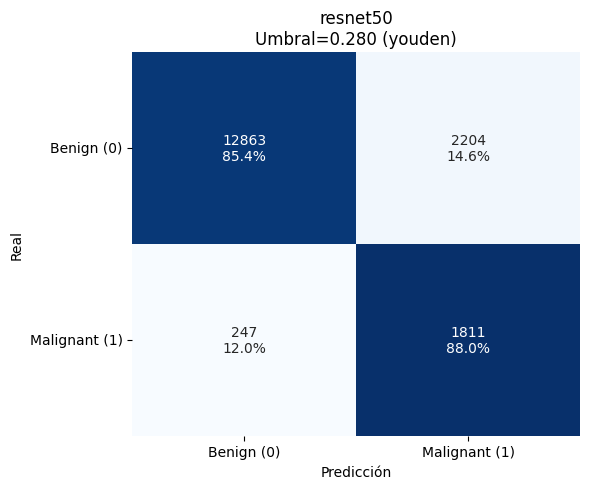

In [128]:
# Después de cargar todos los modelos, crear tabla comparativa
def generate_comparison_table(comparison_folder: str, models: list, split: str = 'test'):
    """Genera tabla comparativa de métricas para todos los modelos"""
    
    results = []
    
    for model in models:
        bundle = load_score_bundle(comparison_folder, model, split)
        y_true = bundle['labels'].astype(int)
        y_prob = bundle['norm_scores'][:, 0] if bundle['norm_scores'].ndim == 2 else bundle['norm_scores']
        
        # Encontrar umbral óptimo
        metrics_list, t_opt, best = threshold_analysis(y_true, y_prob, criterion='youden')
        y_pred = (y_prob >= t_opt).astype(int)
        
        # Calcular métricas
        report_dict = classification_report(y_true, y_pred, 
                                           target_names=['Benign', 'Malignant'], 
                                           output_dict=True)
        
        cm = confusion_matrix(y_true, y_pred)
        tn, fp, fn, tp = cm.ravel()
        
        # Extraer métricas de la clase maligna
        malignant_recall = report_dict['Malignant']['recall']
        malignant_precision = report_dict['Malignant']['precision']
        malignant_f1 = report_dict['Malignant']['f1-score']  # ← F1-SCORE AÑADIDO
        specificity = report_dict['Benign']['recall']
        accuracy = report_dict['accuracy']
        
        # Calcular prevalencia y otros
        n_malignant = np.sum(y_true == 1)
        n_benign = np.sum(y_true == 0)
        prevalence = n_malignant / len(y_true)
        biopsy_ratio = (tp + fp) / tp if tp > 0 else float('inf')
        
        # Calcular índice de Youden manualmente
        youden_index = malignant_recall + specificity - 1
        
        model_name = model.split('_')[0]
        
        results.append({
            'Modelo': model_name,
            'Sensibilidad': f"{malignant_recall:.4f}",
            'Especificidad': f"{specificity:.4f}",
            'Precisión (PPV)': f"{malignant_precision:.4f}",
            'F1-Score': f"{malignant_f1:.4f}",  # ← COLUMNA AÑADIDA
            'Youden': f"{youden_index:.4f}",  # ← COLUMNA AÑADIDA (OPCIONAL)
            'Accuracy': f"{accuracy:.4f}",
            'Umbral': f"{t_opt:.3f}",
            'FN': int(fn),
            'FP': int(fp),
            'VP': int(tp),
            'VN': int(tn),
            'Biopsias/Melanoma': f"{biopsy_ratio:.2f}",
            'Prevalencia': f"{prevalence:.3f}"
        })
    
    df_results = pd.DataFrame(results)
    
    # Ordenar por F1-Score (descendente) - CAMBIO OPCIONAL
    # Puedes ordenar por: 'Sensibilidad', 'F1-Score', 'Youden', etc.
    df_results = df_results.sort_values('F1-Score', ascending=False)
    
    print("\n" + "="*100)
    print("TABLA COMPARATIVA DE MODELOS (Clase Maligna)")
    print("="*100)
    print(df_results.to_string(index=False))
    print("="*100)
    
    # Análisis multi-criterio
    print("\n" + "="*100)
    print("ANÁLISIS POR MÉTRICA INDIVIDUAL")
    print("="*100)
    
    # Mejor sensibilidad
    best_sens_idx = df_results['Sensibilidad'].astype(float).idxmax()
    best_sens_model = df_results.loc[best_sens_idx, 'Modelo']
    best_sens_value = df_results.loc[best_sens_idx, 'Sensibilidad']
    print(f"🎯 Mejor SENSIBILIDAD:    {best_sens_model} ({best_sens_value})")
    
    # Mejor F1-Score
    best_f1_idx = df_results['F1-Score'].astype(float).idxmax()
    best_f1_model = df_results.loc[best_f1_idx, 'Modelo']
    best_f1_value = df_results.loc[best_f1_idx, 'F1-Score']
    print(f"🎯 Mejor F1-SCORE:        {best_f1_model} ({best_f1_value})")
    
    # Mejor Youden
    best_youden_idx = df_results['Youden'].astype(float).idxmax()
    best_youden_model = df_results.loc[best_youden_idx, 'Modelo']
    best_youden_value = df_results.loc[best_youden_idx, 'Youden']
    print(f"🎯 Mejor YOUDEN INDEX:    {best_youden_model} ({best_youden_value})")
    
    # Mejor especificidad
    best_spec_idx = df_results['Especificidad'].astype(float).idxmax()
    best_spec_model = df_results.loc[best_spec_idx, 'Modelo']
    best_spec_value = df_results.loc[best_spec_idx, 'Especificidad']
    print(f"🎯 Mejor ESPECIFICIDAD:   {best_spec_model} ({best_spec_value})")
    
    # Mejor precisión (PPV)
    best_prec_idx = df_results['Precisión (PPV)'].astype(float).idxmax()
    best_prec_model = df_results.loc[best_prec_idx, 'Modelo']
    best_prec_value = df_results.loc[best_prec_idx, 'Precisión (PPV)']
    print(f"🎯 Mejor PRECISIÓN (PPV): {best_prec_model} ({best_prec_value})")
    
    print("="*100)
    
    # Identificar modelo más equilibrado
    print("\n" + "="*100)
    print("EVALUACIÓN GENERAL")
    print("="*100)
    
    # Contar "victorias" por modelo
    metrics_to_check = ['Sensibilidad', 'F1-Score', 'Youden', 'Especificidad', 'Precisión (PPV)']
    wins = {model: 0 for model in df_results['Modelo']}
    
    for metric in metrics_to_check:
        best_idx = df_results[metric].astype(float).idxmax()
        winner = df_results.loc[best_idx, 'Modelo']
        wins[winner] += 1
    
    print("\n📊 Conteo de mejores métricas por modelo:")
    for model, count in sorted(wins.items(), key=lambda x: x[1], reverse=True):
        print(f"   {model}: {count}/5 métricas")
    
    # Modelo ganador general
    overall_best = max(wins, key=wins.get)
    print(f"\n🏆 MODELO MÁS EQUILIBRADO: {overall_best}")
    
    # Detalles del mejor modelo por F1
    print(f"\n📈 DETALLE DEL MEJOR MODELO (por F1-Score): {best_f1_model}")
    best_row = df_results[df_results['Modelo'] == best_f1_model].iloc[0]
    print(f"   • Detecta {best_row['VP']} de {int(best_row['VP']) + best_row['FN']} melanomas")
    print(f"   • Genera {best_row['FP']} falsos positivos de {int(best_row['FP']) + int(best_row['VN'])} casos benignos")
    print(f"   • Requiere {best_row['Biopsias/Melanoma']} biopsias por cada melanoma detectado")
    
    # Advertencia sobre estándar clínico
    max_sens = df_results['Sensibilidad'].astype(float).max()
    if max_sens < 0.95:
        print(f"\n⚠️  ADVERTENCIA: Ningún modelo alcanza el estándar clínico (Sensibilidad ≥95%)")
        print(f"   Mejor sensibilidad: {max_sens:.1%} (brecha de {0.95 - max_sens:.1%})")
    else:
        print(f"\n✅ Al menos un modelo cumple el estándar clínico (Sensibilidad ≥95%)")
    
    print("="*100)
    
    return df_results

# Ejecutar
df_comparison = generate_comparison_table(selected_comparison_folder, selected_models, split)

# Opcional: Exportar a CSV
# df_comparison.to_csv('comparacion_modelos.csv', index=False)

# Luego, mostrar matriz de confusión del mejor modelo según F1-Score
best_f1_idx = df_comparison['F1-Score'].astype(float).idxmax()
best_model_name = df_comparison.loc[best_f1_idx, 'Modelo']

# Encontrar el nombre completo del modelo en la lista original
best_model = [m for m in selected_models if m.startswith(best_model_name)][0]

print(f"\n\n{'='*100}")
print(f"ANÁLISIS DETALLADO DEL MEJOR MODELO: {best_model_name}")
print('='*100)
plot_confusions_with_best_thresholds(selected_comparison_folder, [best_model], split, criterion=opt_criterion)